# G_3 — Figure 3: cumulative incidence of stage transitions

**Input:** `Results/R_Cox_cif_combined.csv`
**Output:** Figure 3

Plots the cumulative incidence functions estimated in the R script, by covariate
and phase. Curves are the absolute probability of successful transition over
time, accounting for cancellation as a competing risk. Requires the R script to
have been run first.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
sns.set_theme(style="white", context="paper", font_scale=1.2)

try:
    df_cif = pd.read_csv("Results/R_Cox_cif_combined.csv")
except FileNotFoundError:
    print("Error: 'all_variables_cif.csv' not found.")
    exit()

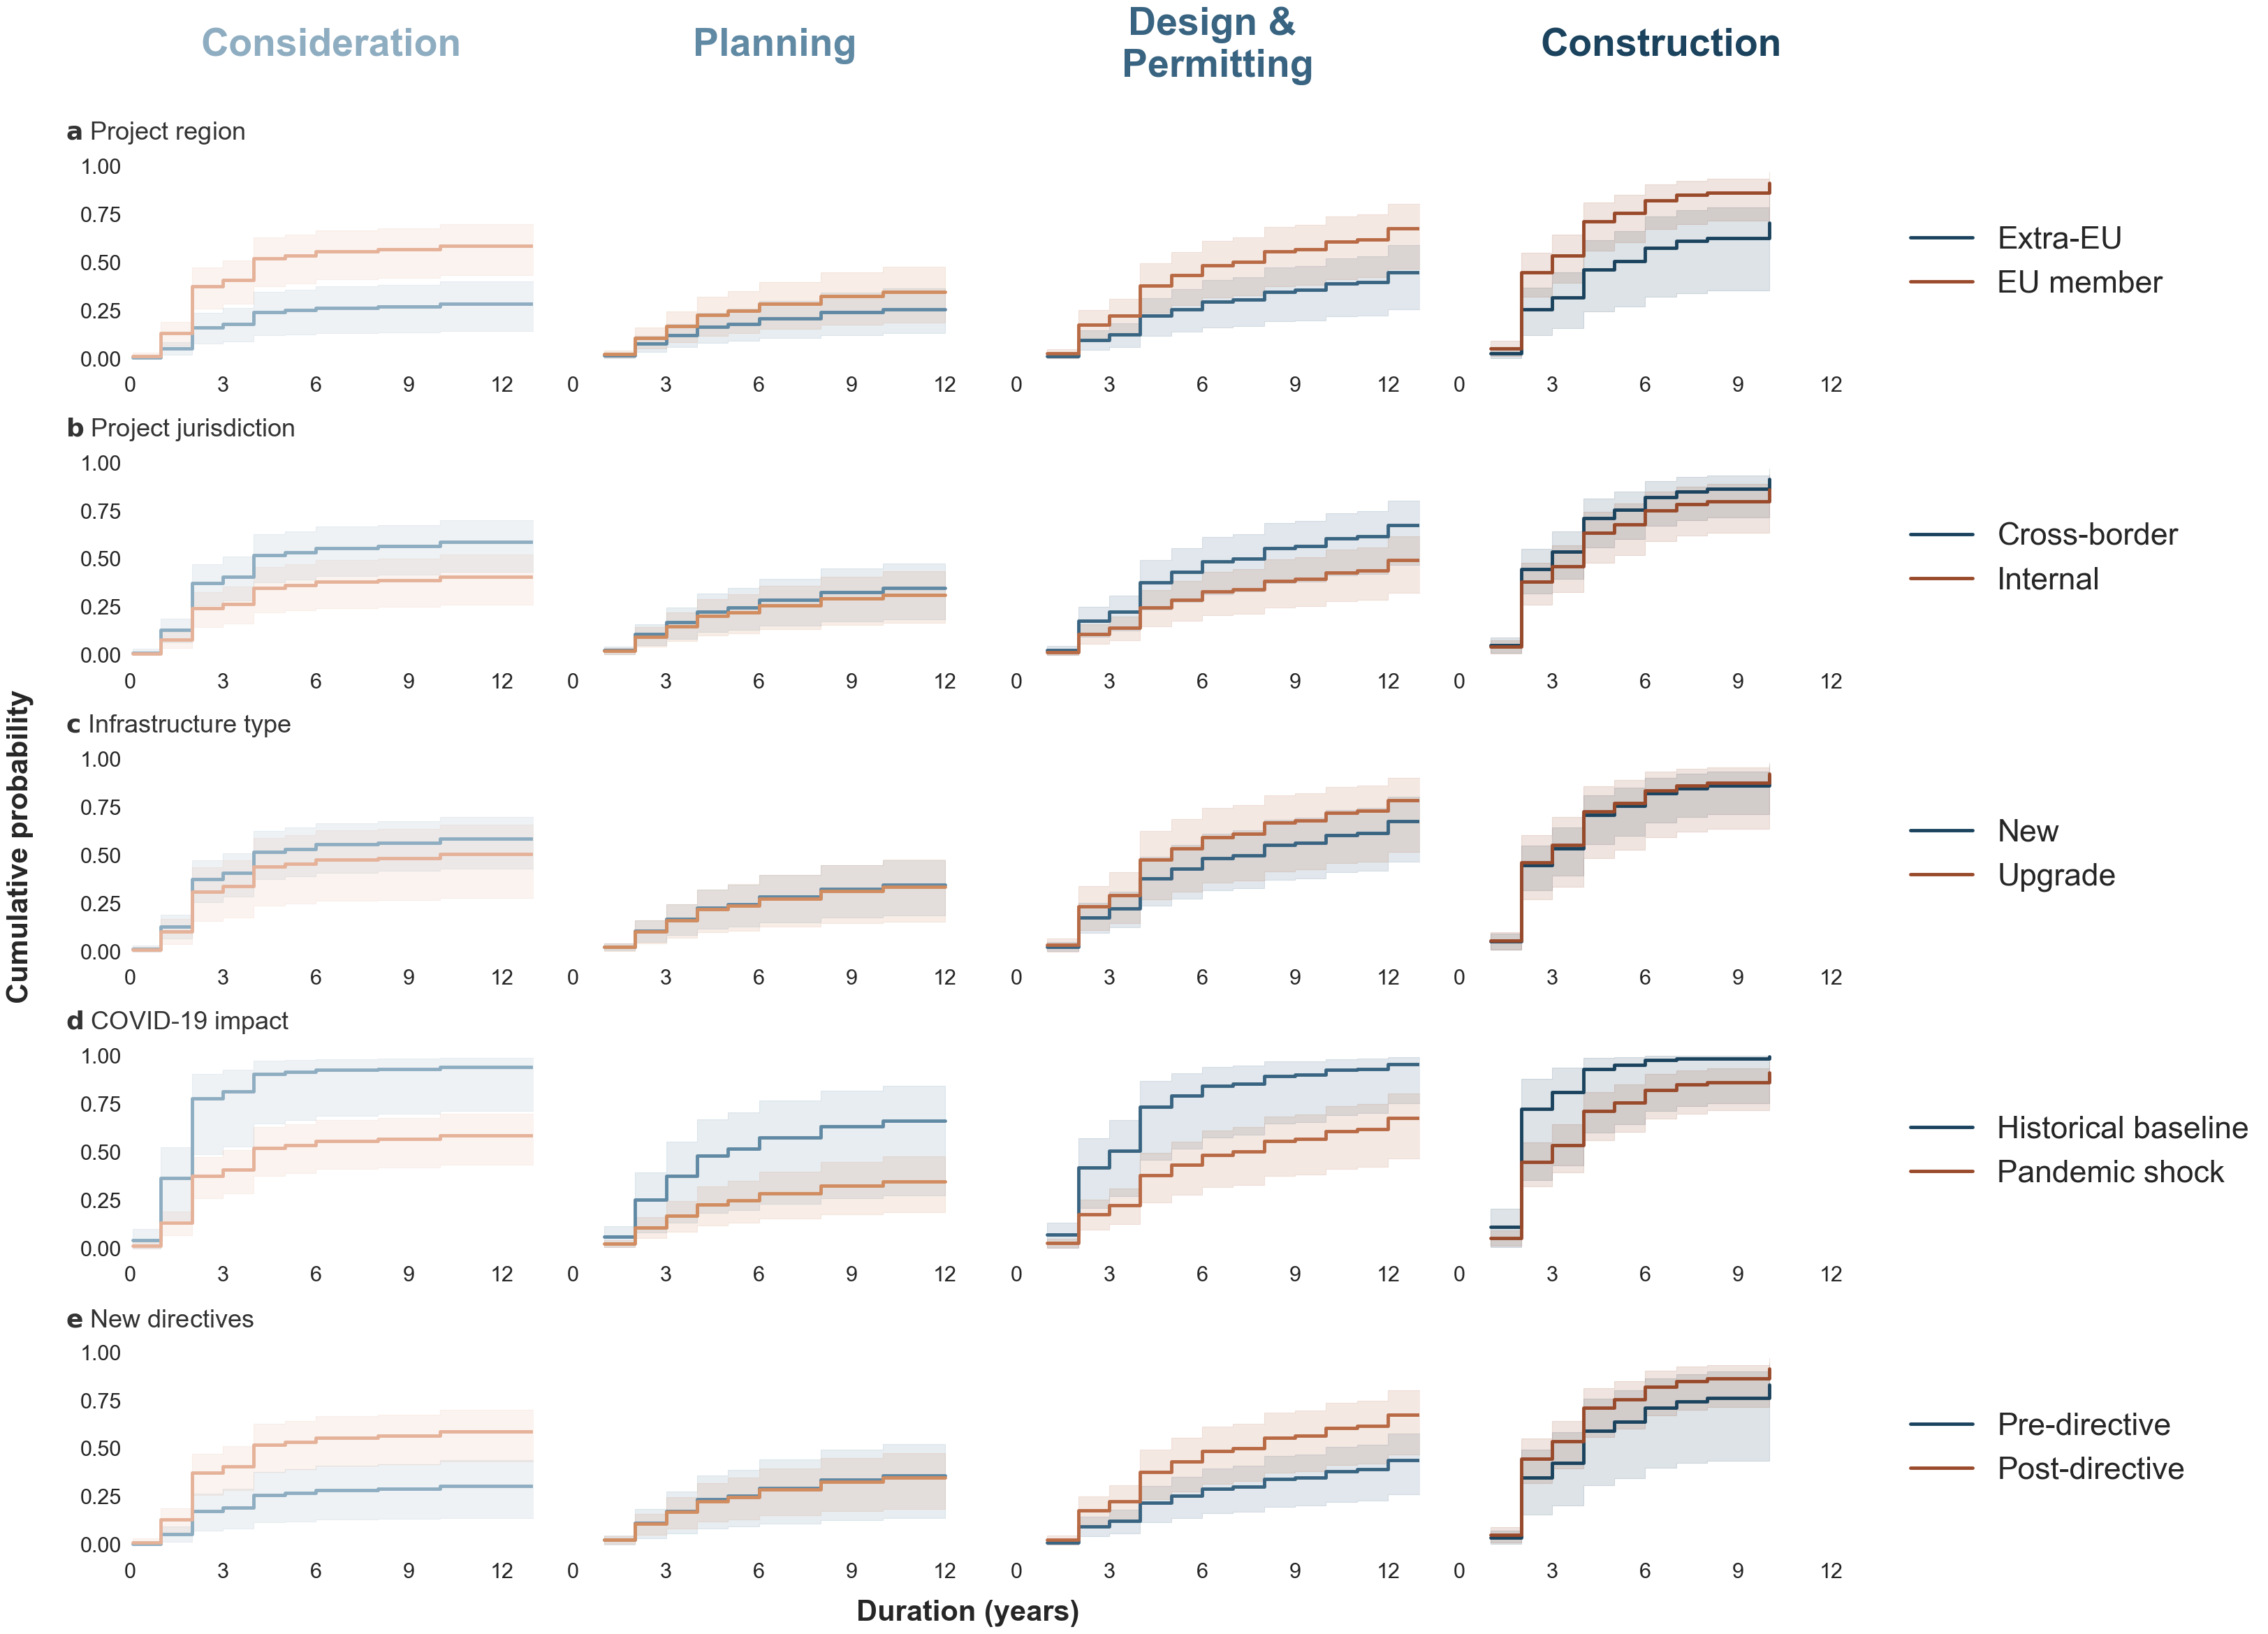

In [3]:
variables_to_plot = ["is_EU", "Project_Jurisdiction", "Infr_Type", 
                     "Covid19", "NewDirective"]

clean_var_names = {
    "is_EU": r"$\bf{a}$ Project region",
    "Project_Region": r"$\bf{a}$ Project region",
    "Project_Jurisdiction": r"$\bf{b}$ Project jurisdiction",
    "Infr_Type": r"$\bf{c}$ Infrastructure type",
    "Covid19": r"$\bf{d}$ COVID-19 impact",
    "NewDirective": r"$\bf{e}$ New directives"
}

phase_titles = [
    "Consideration", 
    "Planning", 
    "Design & \nPermitting", 
    "Construction"
]

palette_base = ['#8EADC1', '#6089A4', '#396481', '#1B435E']
palette_change = ['#E5B299', '#D18C60', '#B86A44', '#994A2B']
palette_third = ['#E5B299', '#D18C60', '#B86A44', '#994A2B']

palettes = [palette_base, palette_change, palette_third]
line_styles = ['-', '--', ':']

fig, axes = plt.subplots(nrows=len(variables_to_plot), ncols=4, 
                         figsize=(32, 26), sharex=True, sharey=True)

plt.subplots_adjust(wspace=0.1, hspace=0.4)

for row_idx, var_name in enumerate(variables_to_plot):
    subset_var = df_cif[
        (df_cif['Variable_Analyzed'] == var_name) &
        (df_cif['Event_Type'] == "success")          # <-- ADDED: pick the event type
    ]
    if subset_var.empty:
        continue

    starting_states = sorted(subset_var['Starting_State'].unique())
    levels = sorted(subset_var['Level_Value'].astype(str).unique())
    pretty_name = clean_var_names.get(var_name, var_name)

    for col_idx, state in enumerate(starting_states):
        ax = axes[row_idx, col_idx]
        subset_state = subset_var[subset_var['Starting_State'] == state]

        for idx, lev in enumerate(levels):
            current_color = palettes[idx % len(palettes)][col_idx]

            data = subset_state[subset_state['Level_Value'].astype(str) == lev].sort_values(by='Time')
            clean_data = data.dropna(subset=['Lower_Event', 'Upper_Event'])   
            has_ci = not clean_data.empty
            plot_data = clean_data if has_ci else data

            if 'Prob_Event' in plot_data.columns and not plot_data.empty:     

                label_text = f'{lev}'
                if var_name == "is_EU":
                    label_text = "Extra-EU" if str(lev) in ("0", "0.0") else "EU member"
                elif var_name == "Covid19":
                    label_text = "Historical baseline" if str(lev) == "0" else "Pandemic shock"
                elif var_name == "NewDirective":
                    label_text = "Pre-directive" if str(lev) == "0" else "Post-directive"

                # Main line
                ax.step(plot_data['Time'], plot_data['Prob_Event'],           
                        label=label_text, color=current_color,
                        linestyle='-', where='post', linewidth=3.5)

                # Confidence band
                if has_ci:
                    ax.fill_between(plot_data['Time'],
                                    plot_data['Lower_Event'],                 
                                    plot_data['Upper_Event'],                 
                                    color=current_color, alpha=0.15, step='post')


        ax.set_xlim([0, 13])
        ax.set_ylim([-0.05, 1.05])
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_xticks([0, 3, 6, 9, 12])

        sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)
        ax.tick_params(bottom=False, left=False, labelsize=22, labelbottom=True)

        if row_idx == 0:
            ax.set_title(phase_titles[col_idx], fontsize=40, y=1.2, va='center',
                         fontweight='bold', color=palette_base[col_idx], pad=70)

        if col_idx == 0:
            ax.text(-0.16, 1.05, pretty_name, rotation=0, va='bottom', ha='left',
                    transform=ax.transAxes, fontsize=26, color='#333333')

        if col_idx == 3:
            ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5),
                      fontsize=32, frameon=False)



fig.supxlabel("Duration (years)", fontsize=30, fontweight='bold', y=0.07)
fig.supylabel("Cumulative probability", fontsize=30, fontweight='bold', x=0.07)


os.makedirs("Images", exist_ok=True)
plt.savefig("Images/CIF.png", dpi=600, bbox_inches='tight')
plt.show()